**1. Import Libraries**

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [55]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**2. Load Dataset**

In [56]:
import pandas as pd

df = pd.read_csv(
    '/content/fake_job_postings.csv',
    engine='python',
    on_bad_lines='skip'
)

print(df.shape)
df.head()

(18254, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**3. Basic EDA**


Fraudulent distribution:
fraudulent
0    0.95097
1    0.04903
Name: proportion, dtype: float64


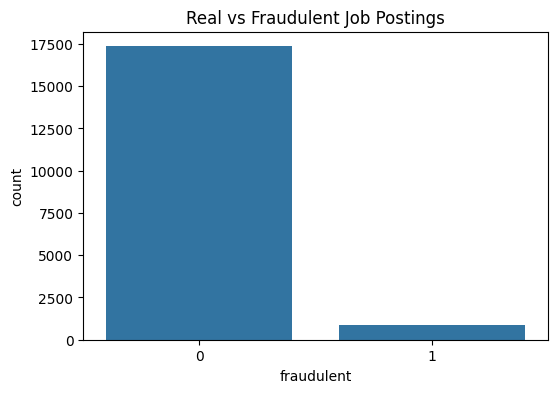

In [57]:
print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts(normalize=True))

# Highly imbalanced → we will use class_weight later
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title('Real vs Fraudulent Job Postings')
plt.show()

**4. Select Relevant Columns**

In [58]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

In [59]:
cat_columns = ['location', 'department', 'salary_range', 'employment_type',
               'required_experience', 'required_education', 'industry', 'function']

binary_columns = ['telecommuting', 'has_company_logo', 'has_questions']

In [60]:
for col in text_columns:
    df[col] = df[col].fillna('')

In [61]:
df['full_text'] = df[text_columns].agg(' '.join, axis=1)


In [62]:
for col in cat_columns:
    df[col] = df[col].fillna('missing')

In [63]:
for col in binary_columns:
    df[col] = df[col].fillna(0)

**5. NLP Preprocessing Function**

In [64]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [65]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

In [66]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
# Apply cleaning
print("Cleaning text...")
df['cleaned_text'] = df['full_text'].apply(clean_text)
print("Text cleaning completed.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning text...
Text cleaning completed.


In [67]:
X_text = df['cleaned_text']
X_cat = df[cat_columns + binary_columns]
y = df['fraudulent']

**7. TF-IDF Vectorization for Text (max_features=5000 to avoid memory issues)**

In [68]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [69]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

**8. Split Data**

In [71]:
X_text_train, X_text_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_text, X_cat, y, test_size=0.2, random_state=42, stratify=y
)

In [72]:
# Transform text
X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

In [73]:
# Transform categorical + binary features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_columns),
        ('binary', 'passthrough', binary_columns)
    ]
)

In [74]:
X_cat_train_processed = preprocessor.fit_transform(X_cat_train)
X_cat_test_processed = preprocessor.transform(X_cat_test)

**9. Combine TF-IDF + Categorical Features (Sparse Matrix → Dense for Keras)**

In [75]:
from scipy.sparse import hstack

In [76]:
X_train = hstack([X_text_train_tfidf, X_cat_train_processed])
X_test = hstack([X_text_test_tfidf, X_cat_test_processed])

# Convert to dense
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print("Final feature matrix shape:", X_train_dense.shape)

Final feature matrix shape: (14603, 9866)


In [77]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.5257795060128178), np.int64(1): np.float64(10.197625698324023)}


In [78]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [79]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

In [80]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     5,051,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,224,449 (19.93 MB)

 Trainable params: 5,224,449 (19.93 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - Precision: 0.3039 - Recall: 0.7108 - accuracy: 0.9070 - loss: 0.3679 - val_Precision: 0.3934 - val_Recall: 0.9664 - val_accuracy: 0.9223 - val_loss: 0.2232
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - Precision: 0.6642 - Recall: 0.9630 - accuracy: 0.9746 - loss: 0.0879 - val_Precision: 0.7544 - val_Recall: 0.8658 - val_accuracy: 0.9788 - val_loss: 0.0697
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - Precision: 0.8116 - Recall: 0.9877 - accuracy: 0.9883 - loss: 0.0444 - val_Precision: 0.7651 - val_Recall: 0.8523 - val_accuracy: 0.9791 - val_loss: 0.0768
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - Precision: 0.9013 - Recall: 0.9982 - accuracy: 0.9946 - loss: 0.0140 - val_Precision: 0.7730 - val_Recall: 0.8456 - val_accuracy: 0.9795 - val_loss: 0.0922
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - Precision: 0.9465 - Recall: 0.9982 - accuracy: 0.9972 - loss: 0.0067 - val_Precision: 0.7514 - 

In [83]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(X_test_dense)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred_prob))

115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3472
           1       0.72      0.89      0.80       179

    accuracy                           0.98      3651
   macro avg       0.86      0.94      0.89      3651
weighted avg       0.98      0.98      0.98      3651

ROC AUC Score: 0.9867945961949385


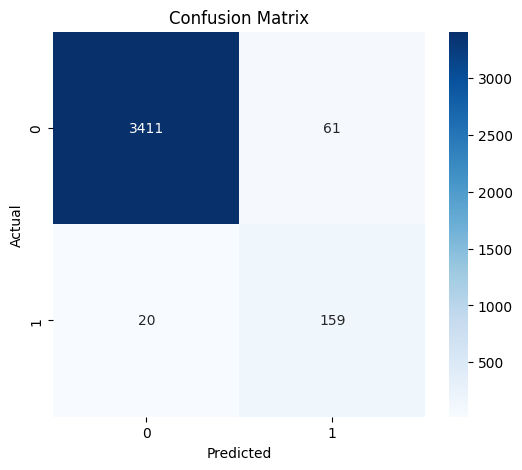

In [84]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [85]:
model.save('fraudulent_job_model.keras')
import joblib
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(preprocessor, 'categorical_preprocessor.pkl')

print("Model and preprocessors saved!")

Model and preprocessors saved!


In [86]:
test_job = {
    'title': 'Data Entry Clerk - Work From Home $5000/week',
    'location': 'missing',
    'department': 'missing',
    'salary_range': 'missing',
    'company_profile': '',
    'description': 'Easy job! Just enter data from home and get paid big money every week. No experience needed.',
    'requirements': 'Must have computer and internet. Small registration fee to start.',
    'benefits': 'Unlimited earning potential! Be your own boss!',
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'missing',
    'required_experience': 'missing',
    'required_education': 'missing',
    'industry': 'missing',
    'function': 'missing'
}

# Prediction function (uses already loaded model, tfidf, preprocessor)
def predict_single_job(job_dict):
    df_new = pd.DataFrame([job_dict])

    # Fill missing columns safely
    for col in text_columns:
        df_new[col] = df_new.get(col, '').fillna('')
    for col in cat_columns:
        df_new[col] = df_new.get(col, 'missing').fillna('missing')
    for col in binary_columns:
        df_new[col] = df_new.get(col, 0).fillna(0)

    # Combine and clean text
    df_new['full_text'] = df_new[text_columns].agg(' '.join, axis=1)
    df_new['cleaned_text'] = df_new['full_text'].apply(clean_text)

    # Vectorize
    text_vec = tfidf.transform(df_new['cleaned_text'])
    cat_vec = preprocessor.transform(df_new[cat_columns + binary_columns])
    X_new = hstack([text_vec, cat_vec]).toarray()

    # Predict
    prob = model.predict(X_new, verbose=0)[0][0]
    prediction = 'FRAUDULENT ⚠️' if prob > 0.5 else 'REAL ✅'

    return prob, prediction

# Run prediction
probability, result = predict_single_job(test_job)

print("\n=== SINGLE SAMPLE PREDICTION ===\n")
print(f"Job Title: {test_job['title']}")
print(f"Fraud Probability: {probability:.4f}")
print(f"Final Prediction : {result}")

if probability > 0.5:
    print("\n🚨 This job posting looks highly suspicious / likely fake!")
else:
    print("\n✅ This job posting appears legitimate.")


=== SINGLE SAMPLE PREDICTION ===

Job Title: Data Entry Clerk - Work From Home $5000/week
Fraud Probability: 1.0000
Final Prediction : FRAUDULENT ⚠️

🚨 This job posting looks highly suspicious / likely fake!
